In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [32]:
orig_activity = pd.read_csv('data/GeneList_K562.txt', sep='\t')
orig_activity

,chr,start,end,name,score,strand,Ensembl_ID,gene_type,symbol,tss,...,DHS.ENCFF860XAE.sorted.bam.RPM.TSS1Kb,DHS.ENCFF860XAE.sorted.bam.readCount.quantile.TSS1Kb,DHS.ENCFF860XAE.sorted.bam.RPM.quantile.TSS1Kb,DHS.ENCFF860XAE.sorted.bam.RPKM.TSS1Kb,DHS.ENCFF860XAE.sorted.bam.RPKM.quantile.TSS1Kb,DHS.RPM.TSS1Kb,DHS.RPM.quantile.TSS1Kb,DHS.RPKM.TSS1Kb,DHS.RPKM.quantile.TSS1Kb,PromoterActivityQuantile
0,chr1,34610,36081,FAM138F,0,-,ENSG00000282591,lincRNA,FAM138F,36081,...,0.769285,0.432691,0.432691,0.769285,0.432691,0.769285,0.432691,0.769285,0.432691,0.508105
1,chr1,34610,36081,FAM138A,0,-,ENSG00000237613,lincRNA,FAM138A,36081,...,0.769285,0.432691,0.432691,0.769285,0.432691,0.769285,0.432691,0.769285,0.432691,0.508105
2,chr1,69090,70008,OR4F5,0,+,ENSG00000186092,protein_coding,OR4F5,69090,...,0.937566,0.446797,0.446797,0.937566,0.446797,0.937566,0.446797,0.937566,0.446797,0.524146
3,chr1,817370,819834,FAM87B,0,+,ENSG00000177757,lincRNA,FAM87B,817370,...,1.466450,0.483887,0.483887,1.466450,0.483887,1.466450,0.483887,1.466450,0.483887,0.496250
4,chr1,826205,827522,LINC00115,0,-,ENSG00000225880,lincRNA,LINC00115,827522,...,12.428763,0.909005,0.909005,12.428763,0.909005,12.428763,0.909005,12.428763,0.909005,0.952192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20661,chrY,21382973,21386360,PRORY,0,-,ENSG00000183146,protein_coding,PRORY,21386360,...,0.000000,0.005734,0.005734,0.000000,0.005734,0.000000,0.005734,0.000000,0.005734,0.003678
20662,chrY,21583599,21594666,TTTY13,0,-,ENSG00000184991,lincRNA,TTTY13,21594666,...,0.000000,0.005734,0.005734,0.000000,0.005734,0.000000,0.005734,0.000000,0.005734,0.003678
20663,chrY,22296797,22298876,TTTY5,0,-,ENSG00000215560,lincRNA,TTTY5,22298876,...,0.000000,0.005734,0.005734,0.000000,0.005734,0.000000,0.005734,0.000000,0.005734,0.003678
20664,chrY,23129354,23199092,DAZ1,0,-,ENSG00000188120,protein_coding,DAZ1,23199092,...,0.000000,0.005734,0.005734,0.000000,0.005734,0.000000,0.005734,0.000000,0.005734,0.003678


In [14]:
ihec_activity = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/PromotersK562.H3K27ac.tab', sep='\t', names=['gene_id', 'size', 'covered', 'sum', 'mean0', 'mean'])
ihec_activity

,gene_id,size,covered,sum,mean0,mean
0,ENSG00000186092,1000,1000,0.000,0.000000,0.000000
1,ENSG00000187634,1000,1000,122.686,0.122686,0.122686
2,ENSG00000188976,1000,1000,7424.410,7.424410,7.424410
3,ENSG00000187961,1000,1000,5172.200,5.172200,5.172200
4,ENSG00000187583,1000,1000,5719.150,5.719150,5.719150
...,...,...,...,...,...,...
18372,ENSG00000155962,1000,1000,8528.710,8.528710,8.528710
18373,ENSG00000168939,1000,1000,25763.000,25.763000,25.763000
18374,ENSG00000185973,1000,1000,26074.200,26.074200,26.074200
18375,ENSG00000124333,1000,1000,19404.800,19.404800,19.404800


In [15]:
ihec_activity = ihec_activity.merge(orig_activity[['Ensembl_ID', 'H3K27ac.RPM.TSS1Kb']], left_on='gene_id', right_on='Ensembl_ID', how='left')
ihec_activity = ihec_activity[['gene_id', 'size', 'covered', 'mean0', 'mean', 'H3K27ac.RPM.TSS1Kb']]

In [16]:
ihec_activity

,gene_id,size,covered,mean0,mean,H3K27ac.RPM.TSS1Kb
0,ENSG00000186092,1000,1000,0.000000,0.000000,5.074535
1,ENSG00000187634,1000,1000,0.122686,0.122686,0.118012
2,ENSG00000188976,1000,1000,7.424410,7.424410,5.192548
3,ENSG00000187961,1000,1000,5.172200,5.172200,2.360249
4,ENSG00000187583,1000,1000,5.719150,5.719150,3.540374
...,...,...,...,...,...,...
18404,ENSG00000155962,1000,1000,8.528710,8.528710,18.409943
18405,ENSG00000168939,1000,1000,25.763000,25.763000,1.180125
18406,ENSG00000185973,1000,1000,26.074200,26.074200,23.602491
18407,ENSG00000124333,1000,1000,19.404800,19.404800,29.031063


In [28]:
# drop na rows
ihec_activity = ihec_activity.dropna(subset=['H3K27ac.RPM.TSS1Kb'])

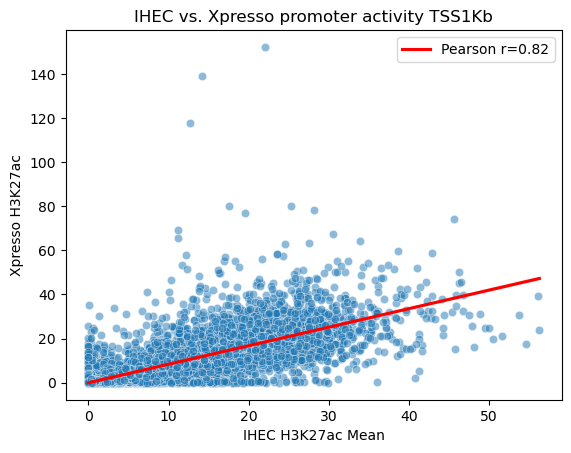

In [31]:
pearsonr, _ = stats.pearsonr(ihec_activity['mean'], ihec_activity['H3K27ac.RPM.TSS1Kb'])
sns.scatterplot(data=ihec_activity, x='mean', y='H3K27ac.RPM.TSS1Kb', alpha=0.5)
sns.regplot(data=ihec_activity, x='mean', y='H3K27ac.RPM.TSS1Kb', scatter=False, color='red', label=f'Pearson r={pearsonr:.2f}')
plt.xlabel('IHEC H3K27ac Mean')
plt.ylabel('Xpresso H3K27ac')
plt.title('IHEC vs. Xpresso promoter activity TSS1Kb')
plt.legend()

plt.show()